# 📊 EDA - Tabular Data: Advertisement Click on Ad
**Course:** P4AI-DS (CO3135) - HCMUT
**Assignment 1:** Exploratory Data Analysis

**Dataset:** [Advertisement - Click on Ad](https://www.kaggle.com/datasets/gabrielsantello/advertisement-click-on-ad)

**Description:** 1000 internet user records, predicting whether they clicked on an ad.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ Import thành công!')

✅ Import thành công!


## 2. Load và kiểm tra dữ liệu

In [2]:
df = pd.read_csv('advertising.csv')

print('=' * 60)
print('📋 5 HÀNG ĐẦU TIÊN CỦA DATASET')
print('=' * 60)
df.head()

📋 5 HÀNG ĐẦU TIÊN CỦA DATASET


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [3]:
print('=' * 60)
print('📊 THÔNG TIN TỔNG QUAN')
print('=' * 60)

print(f'\n🔹 Kích thước dataset: {df.shape[0]} hàng x {df.shape[1]} cột')
print(f'\n🔹 Danh sách các cột:')
for i, col in enumerate(df.columns, 1):
    print(f'   {i}. {col} ({df[col].dtype})')

print(f'\n🔹 Thông tin chi tiết:')
df.info()

📊 THÔNG TIN TỔNG QUAN

🔹 Kích thước dataset: 1000 hàng x 10 cột

🔹 Danh sách các cột:
   1. Daily Time Spent on Site (float64)
   2. Age (int64)
   3. Area Income (float64)
   4. Daily Internet Usage (float64)
   5. Ad Topic Line (str)
   6. City (str)
   7. Male (int64)
   8. Country (str)
   9. Timestamp (str)
   10. Clicked on Ad (int64)

🔹 Thông tin chi tiết:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null

## 3. Thống kê mô tả (Descriptive Statistics)

In [4]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


## 4. Kiểm tra Missing Values & Duplicates

In [5]:
print('=' * 60)
print('❓ KIỂM TRA MISSING VALUES')
print('=' * 60)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

total_missing = df.isnull().sum().sum()
print(f'\n📌 Tổng missing values: {total_missing}')

print(f'\n🔄 KIỂM TRA DUPLICATES')
dup_count = df.duplicated().sum()
print(f'📌 Số hàng bị trùng lặp: {dup_count}')

❓ KIỂM TRA MISSING VALUES
                          Missing Count  Missing %
Daily Time Spent on Site              0        0.0
Age                                   0        0.0
Area Income                           0        0.0
Daily Internet Usage                  0        0.0
Ad Topic Line                         0        0.0
City                                  0        0.0
Male                                  0        0.0
Country                               0        0.0
Timestamp                             0        0.0
Clicked on Ad                         0        0.0

📌 Tổng missing values: 0

🔄 KIỂM TRA DUPLICATES
📌 Số hàng bị trùng lặp: 0


## 5. Phân phối Target Variable (Clicked on Ad)

Không click (0): 500 (50.0%)
Click (1): 500 (50.0%)


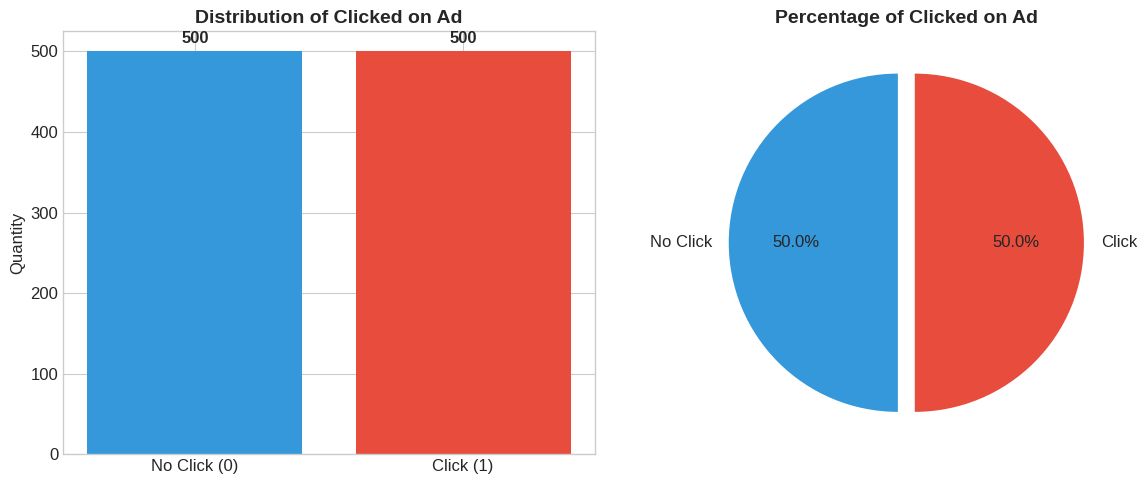

In [6]:
target_counts = df['Clicked on Ad'].value_counts()
print(f'Không click (0): {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)')
print(f'Click (1): {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#3498db', '#e74c3c']
axes[0].bar(['No Click (0)', 'Click (1)'], target_counts.values, color=colors)
axes[0].set_title('Distribution of Clicked on Ad', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantity')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['No Click', 'Click'],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Percentage of Clicked on Ad', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('tabular_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Phân phối các biến số (Numerical Features)

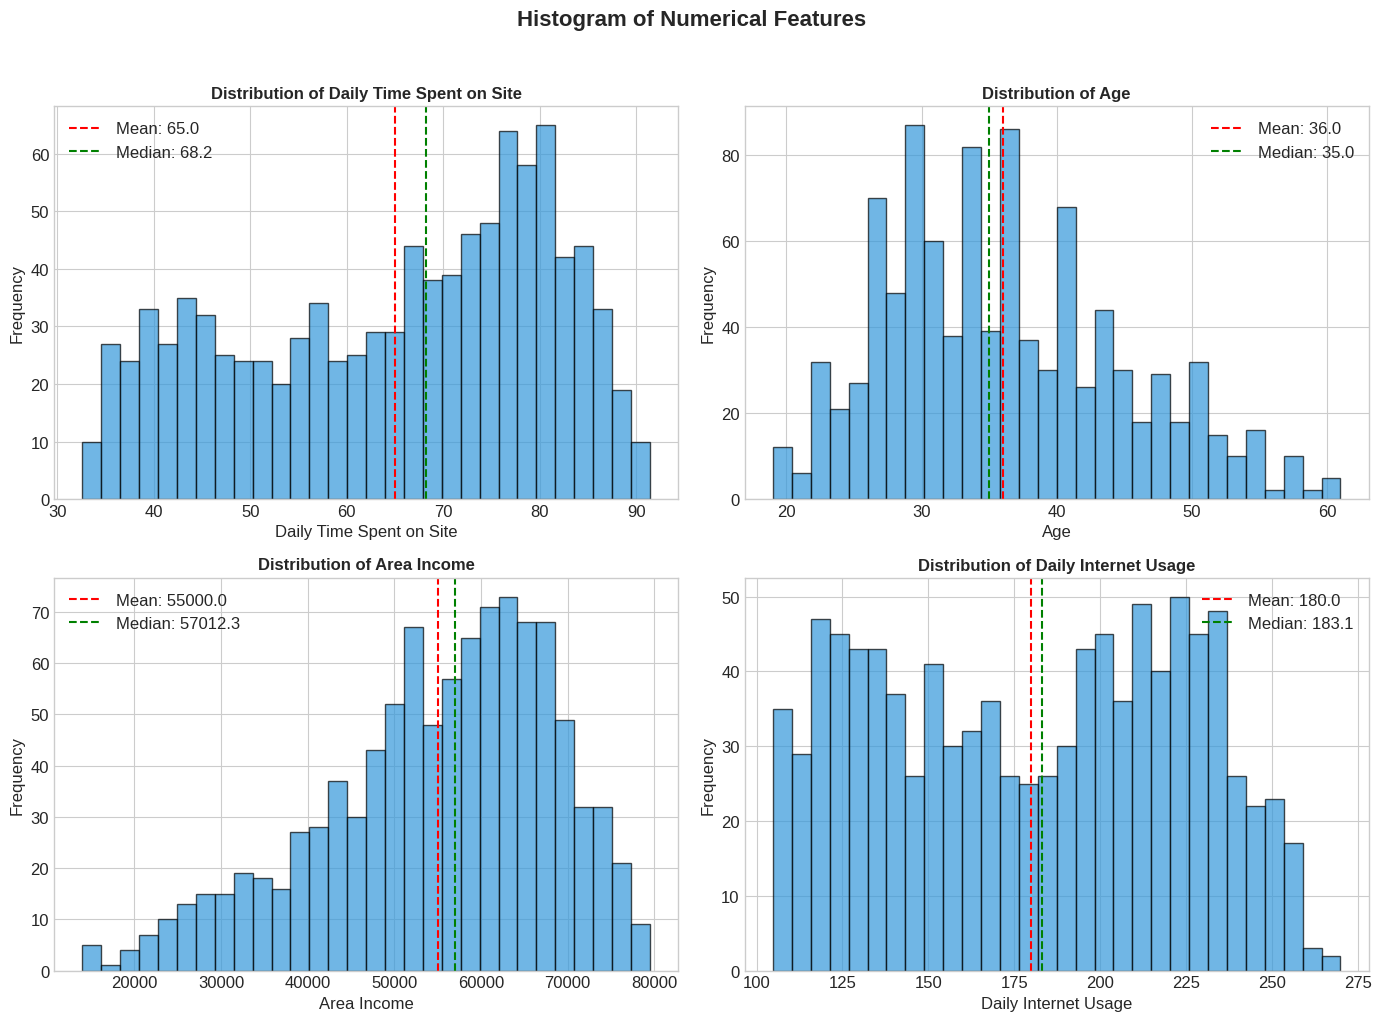

In [7]:
numerical_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Histogram of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tabular_02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Boxplot - So sánh theo Clicked on Ad

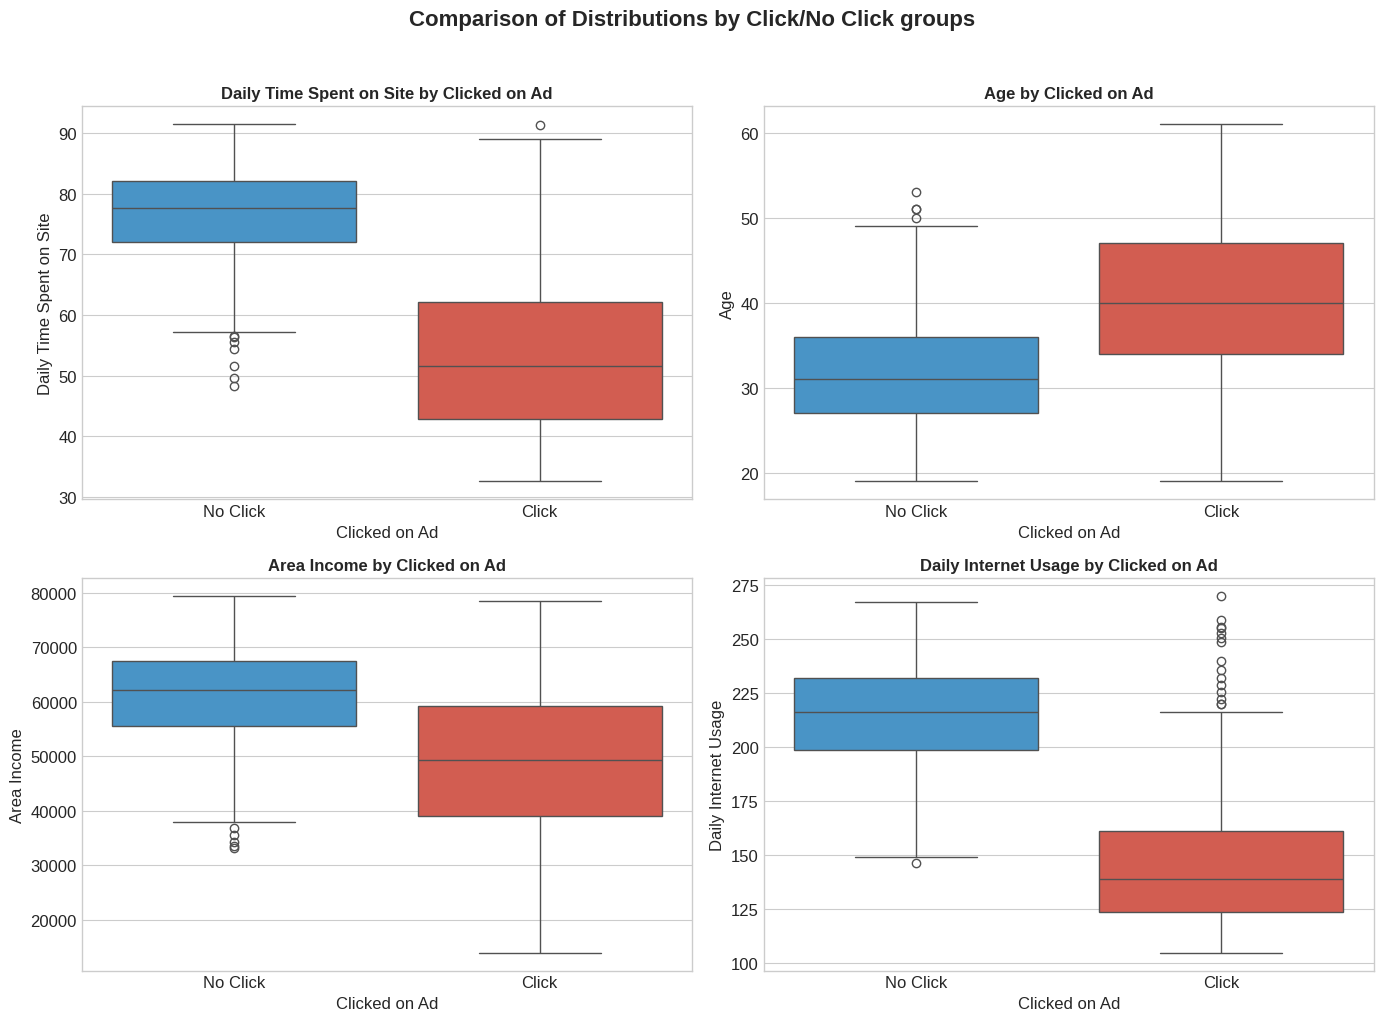

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x='Clicked on Ad', y=col, data=df, ax=axes[i],
                palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} by Clicked on Ad', fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['No Click', 'Click'])

plt.suptitle('Comparison of Distributions by Click/No Click groups',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tabular_03_boxplot_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Correlation Heatmap

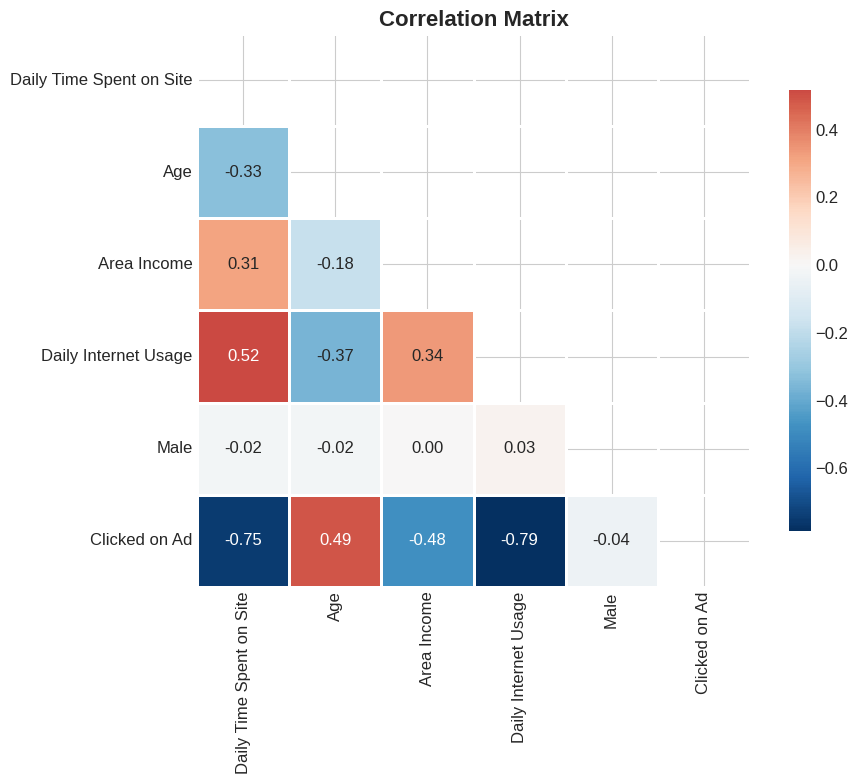


📌 Nhận xét:
- Clicked on Ad tương quan ÂM mạnh với Daily Time Spent on Site và Daily Internet Usage
- Clicked on Ad tương quan DƯƠNG với Age
- Daily Time Spent on Site và Daily Internet Usage tương quan dương mạnh với nhau


In [9]:
numeric_df = df[['Daily Time Spent on Site', 'Age', 'Area Income',
                 'Daily Internet Usage', 'Male', 'Clicked on Ad']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, square=True,
            linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('tabular_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Nhận xét:')
print('- Clicked on Ad tương quan ÂM mạnh với Daily Time Spent on Site và Daily Internet Usage')
print('- Clicked on Ad tương quan DƯƠNG với Age')
print('- Daily Time Spent on Site và Daily Internet Usage tương quan dương mạnh với nhau')

## 9. Pairplot

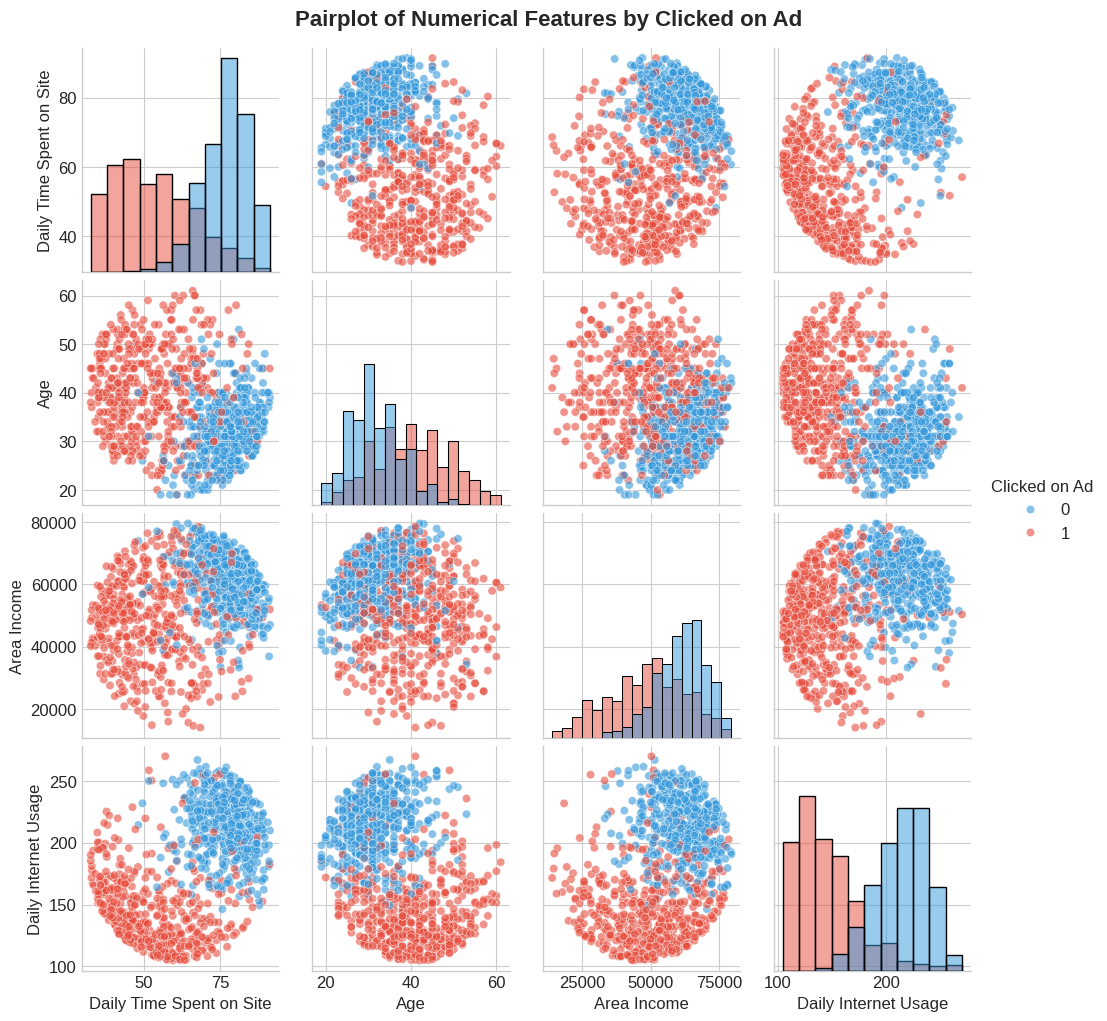

In [10]:
sns.pairplot(df[['Daily Time Spent on Site', 'Age', 'Area Income',
                 'Daily Internet Usage', 'Clicked on Ad']],
             hue='Clicked on Ad', palette=['#3498db', '#e74c3c'],
             diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Numerical Features by Clicked on Ad', y=1.02,
             fontsize=16, fontweight='bold')
plt.savefig('tabular_05_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Phân tích theo thời gian

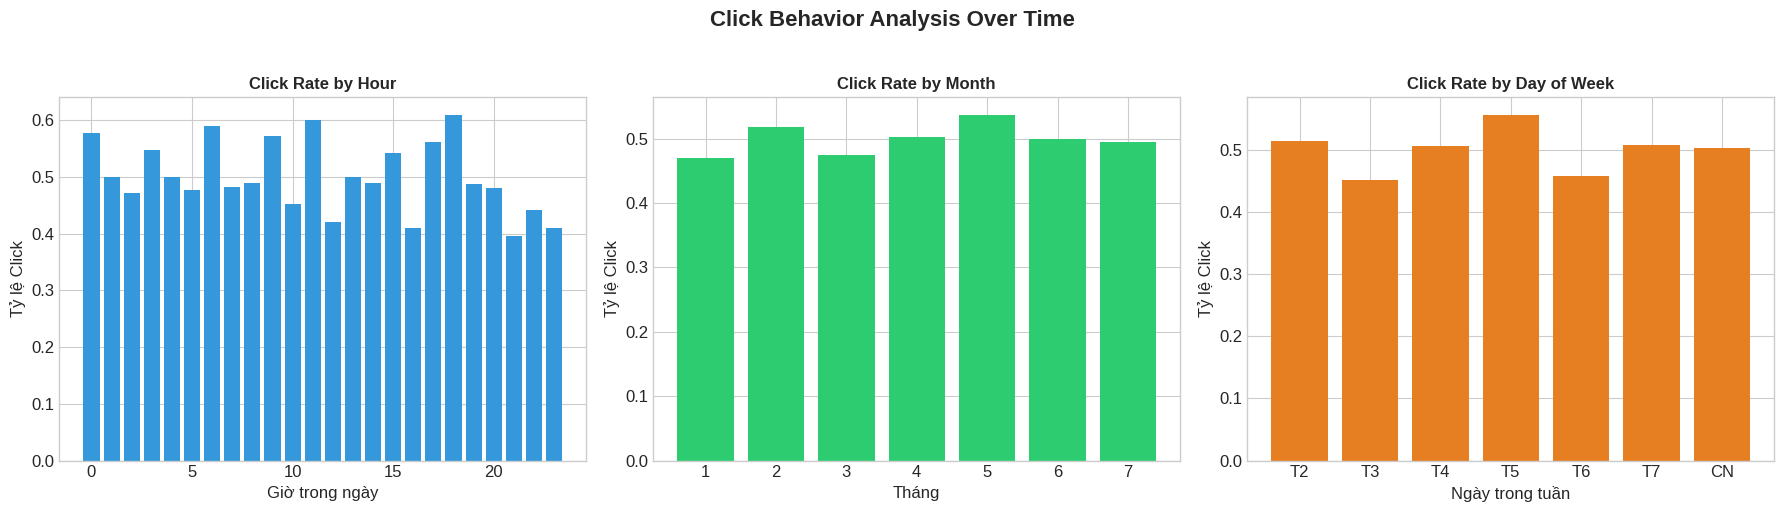

In [11]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

click_by_hour = df.groupby('Hour')['Clicked on Ad'].mean()
axes[0].bar(click_by_hour.index, click_by_hour.values, color='#3498db')
axes[0].set_title('Click Rate by Hour', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giờ trong ngày')
axes[0].set_ylabel('Tỷ lệ Click')

click_by_month = df.groupby('Month')['Clicked on Ad'].mean()
axes[1].bar(click_by_month.index, click_by_month.values, color='#2ecc71')
axes[1].set_title('Click Rate by Month', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Tỷ lệ Click')

click_by_dow = df.groupby('DayOfWeek')['Clicked on Ad'].mean()
days = ['T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'CN']
axes[2].bar(days, click_by_dow.values, color='#e67e22')
axes[2].set_title('Click Rate by Day of Week', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Ngày trong tuần')
axes[2].set_ylabel('Tỷ lệ Click')

plt.suptitle('Click Behavior Analysis Over Time',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tabular_06_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Top quốc gia & Giới tính

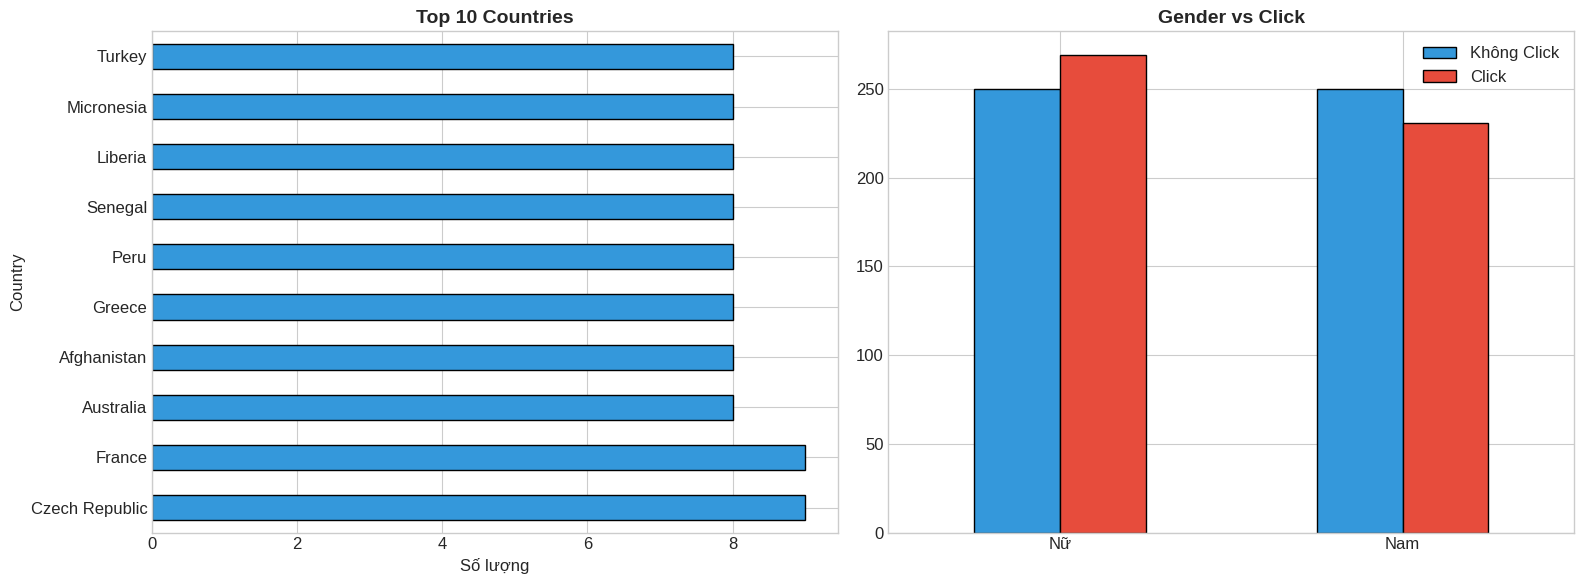

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top countries
top_countries = df['Country'].value_counts().head(10)
top_countries.plot(kind='barh', color='#3498db', ax=axes[0], edgecolor='black')
axes[0].set_title('Top 10 Countries', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số lượng')

# Gender vs Click
gender_click = pd.crosstab(df['Male'], df['Clicked on Ad'])
gender_click.index = ['Nữ', 'Nam']
gender_click.columns = ['Không Click', 'Click']
gender_click.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Gender vs Click', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Nữ', 'Nam'], rotation=0)
axes[1].legend()

plt.tight_layout()
plt.savefig('tabular_07_country_gender.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Phát hiện Outliers

In [13]:
print('🔍 PHÁT HIỆN OUTLIERS (IQR Method)')
print('=' * 60)

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'📌 {col}: {len(outliers)} outliers '
          f'({len(outliers)/len(df)*100:.1f}%) '
          f'[Range: {lower:.1f} - {upper:.1f}]')

🔍 PHÁT HIỆN OUTLIERS (IQR Method)
📌 Daily Time Spent on Site: 0 outliers (0.0%) [Range: 10.6 - 119.3]
📌 Age: 0 outliers (0.0%) [Range: 9.5 - 61.5]
📌 Area Income: 9 outliers (0.9%) [Range: 19373.6 - 93128.9]
📌 Daily Internet Usage: 0 outliers (0.0%) [Range: 18.9 - 338.7]


## 13. Tổng kết Findings

**1. TỔNG QUAN DATASET:**
- 1000 bản ghi, 10 cột, không có missing values, không có duplicates.
- 4 cột số (Time, Age, Income, Internet Usage), 4 cột text, 2 cột nhị phân.

**2. PHÂN PHỐI TARGET:**
- Cân bằng hoàn hảo: 500 click (50%) vs 500 không click (50%).
- Không cần xử lý class imbalance.

**3. INSIGHTS QUAN TRỌNG:**
- Người CLICK quảng cáo: tuổi cao hơn, thu nhập thấp hơn, dùng internet ít hơn.
- Daily Time Spent on Site và Daily Internet Usage tương quan âm mạnh với Clicked on Ad.
- Age tương quan dương với Clicked on Ad.

**4. VẤN ĐỀ CẦN XỬ LÝ:**
- Cột 'Ad Topic Line' gần như unique → nên drop hoặc dùng NLP.
- Cột 'City' có quá nhiều giá trị unique → nên drop hoặc encode.
- Cột 'Timestamp' nên extract features (hour, month, day of week).
- Một số outliers nhẹ ở Area Income.